In [6]:
%matplotlib inline

In [7]:
import pyrogue
import scipy.signal as signal
print(pyrogue.__version__)

6.8.5


In [8]:
from pyrogue import interfaces
pyrogue.interfaces

<module 'pyrogue.interfaces' from '/opt/venv/lib/python3.12/site-packages/pyrogue/interfaces/__init__.py'>

In [9]:
import matplotlib
import pysmurf.client
import matplotlib.pylab as plt
import numpy as np
import sys
import os
port = 9009
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/b33/experiment_b33_rfc1-2_C05-40_s4_rfsoc_extref.cfg")
S = pysmurf.client.SmurfControl(server_port=port,
                                cfg_file=config_file,
                                setup=False,
                                make_logfile=False)

TypeError: Logger.__init__() got an unexpected keyword argument 'server_port'

In [1]:
import pysmurf
print(pysmurf.__version__)

9.0.0+41.ga23a2ac6.dirty


In [10]:
print(pysmurf.__file__)

/usr/local/src/pysmurf/python/pysmurf/__init__.py


In [ ]:
import pysmurf
print(pysmurf.__version__)

In [23]:
S.get_rogue_version()

'v6.8.5'

In [24]:
S.get_fpga_git_hash_short()

'7d4fca8'

In [25]:
plt.ion()

Only once per power on ; configure hardware

In [26]:
S.setup()

[ 2026-07-23 00:02:18 ]  System already configured once while this Rogue server has been up.
[ 2026-07-23 00:02:18 ]  If you really want to configure again, run setup with force_configure=True.


False

Function get_att_uc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_dc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_uc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_dc called, but not implemented on RFSoC.  Skipping call and returning None!
Function set_att_uc called, but not implemented on RFSoC.  Skipping call and returning None!
Function set_att_dc called, but not implemented on RFSoC.  Skipping call and returning None!
[ 2026-07-23 00:02:22 ]  Running full band resp
Function get_att_uc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_dc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_uc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_dc called, but not implemented on RFSoC.  Skipping call and returning None!
Function get_att_uc ca

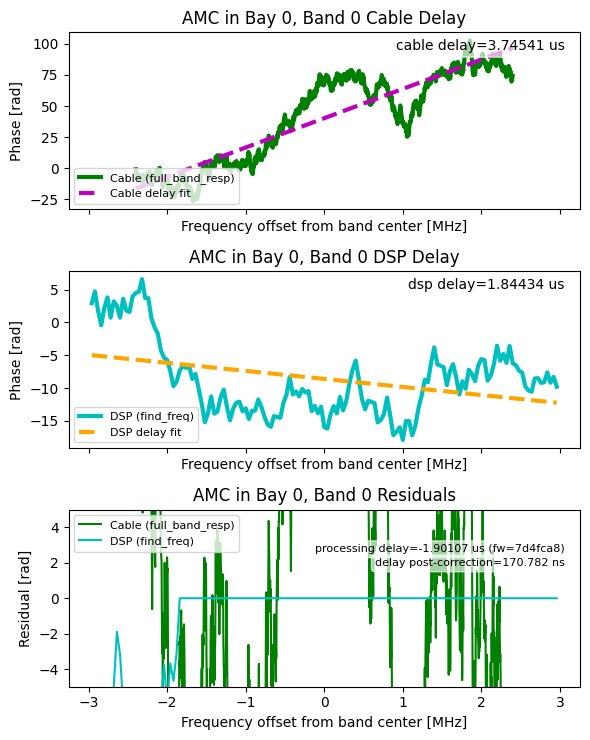

(np.float64(1.8443384645351693), np.float64(0.1707820036351995))

In [27]:
S.estimate_phase_delay(0)

[ 2026-07-23 00:02:42 ]  No tone_power given. Using value in config file: 12
[ 2026-07-23 00:02:42 ]  Sweeping across frequencies 500.0MHz to 1000.0MHz
[ 2026-07-23 00:02:42 ]  Working on band 0
[ 2026-07-23 00:03:06 ]  serial find freq complete


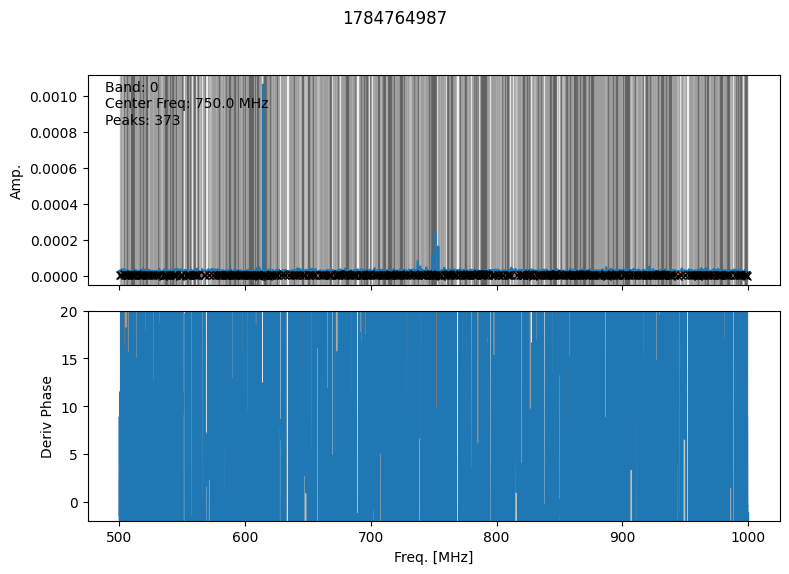

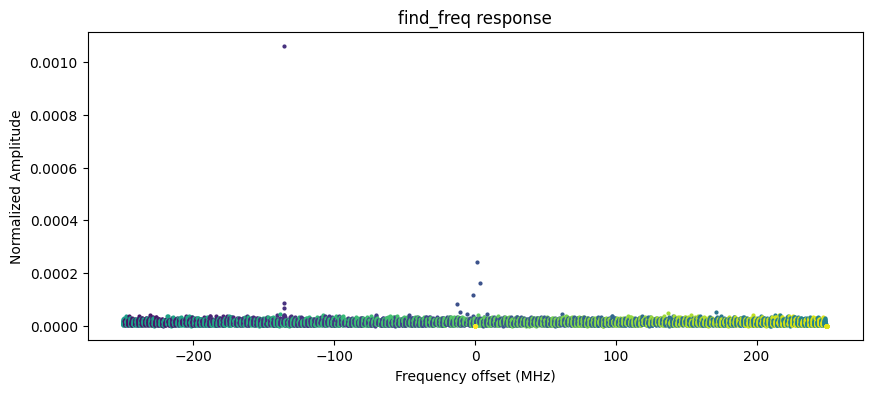

CPU times: user 6.38 s, sys: 48.2 ms, total: 6.43 s
Wall time: 28.9 s


(array([[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]], shape=(512, 31)),
 array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        ...,
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
        [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]],
       shape=(512, 31)))

In [28]:
%%time
S.find_freq(0,make_plot=True,show_plot=True)

In [12]:
S.save_state('/data/smurf_data/zcu208-cryo-det-PreSpectra-rogue6-7d4fca8-prestream.yml')

Makes sense.  The RFSoC software isn't yet smart enough to know it's centered at baseband, so tell it; 

In [10]:
band=0
S.set_band_center_mhz(band,750) # baseband center

Make sure we're in extref mode

In [11]:
S.set_timing_mode('ext_ref')

[ 2026-07-17 01:48:44 ]  System already configured for ext_ref timing, doing nothing.


## Testing power levels

In [12]:
S.set_fixed_tone(750,12)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


(0, np.int64(0))

In [18]:
S.which_on(0)

array([  0,  32, 272])

In [17]:
S.set_fixed_tone(770,15)

(0, np.int64(272))

# IQ Streaming

We're going to take I,Q data.  This is not standard data-taking, so have to set some flags to enable it.  Currently, this data mode is only supported for one bay at a time.  So we have to select I/Q data mode, and tell it which bay to give us data from.  The "bay" concept is only meaningful in the original SMuRF ATCA hardware context; for the RFSoC bay 0 just means bands 0,1,2,3 and bay 1 means bands 4,5,6,7.

In [13]:
S.set_mode_stream(1) # stream I/Q, not uMUX demod FR
S.set_bay_sel_stream(0) # stream I/Q from bay 0 = bands 0,1,2,3

In [14]:
S.set_lms_gain(band,7) # 7 means don't truncate as much as possible

In [15]:
S.band_off(band) # turn off all tones

In [16]:
# Set tones to stream IQ Data
# steps of 1 for second arg is 3 dB, 15 is higher than 12
S.set_fixed_tone(511.101,12)
S.set_fixed_tone(575.292,12)
S.set_fixed_tone(636.383,12)
S.set_fixed_tone(694.474,12)
S.set_fixed_tone(728.565,12)
S.set_fixed_tone(755.656,12)
S.set_fixed_tone(812.747,12)
S.set_fixed_tone(879.838,12)
S.set_fixed_tone(931.929,12)
S.set_fixed_tone(989.010,12)

(0, np.int64(454))

In [17]:
# Channels (from the OPFB)
S.which_on(band)

array([ 50,  88, 108, 151, 237, 239, 267, 313, 320, 454])

In [18]:
# Stream Data at 32 kHz

In [19]:
S.stream_data_off()
S.flux_ramp_setup(32,0)

[ 2026-06-15 21:55:42 ]  Waiting 0.15 seconds after...
[ 2026-06-15 21:55:42 ]  Done waiting.
[ 2026-06-15 21:55:42 ]  Percent full scale = 0.000%


In [20]:
S.set_filter_disable(True) # doesn't work on PreSpectra v0x04 data
S.set_downsample_factor(1) # NO DOWNSAMPLING

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=32000.0
S.get_downsample_factor()=1
S.get_filter_disable()=True


In [21]:
from prespectra_streaming_example import configure_remap_lut, take_prespectra_data, read_prespectra_data

In [22]:
# configure the remap LUT
active_channels = S.which_on(band)
configure_remap_lut(S, active_channels, band=0)

Remap LUT: slots 0-9 → channels [ 50  88 108 151 237 239 267 313 320 454]


In [23]:
# take data
data_file = take_prespectra_data(S, meas_time=1)

Using existing downsample_factor=1
Writing to: /data/smurf_data/20260615/1781560350/outputs/1781560554.dat
Done.  /data/smurf_data/20260615/1781560350/outputs/1781560554.dat


In [24]:
# read data
timestamps, iq = read_prespectra_data(data_file)

Processing data records from /data/smurf_data/20260615/1781560350/outputs/1781560554.dat
Processed 672 data records from /data/smurf_data/20260615/1781560350/outputs/1781560554.dat
Processed a total of 672 data records
Read 672 frames, shape (672, 32, 64) = (frames, timeslices, slots)


In [25]:
iq.shape

(672, 32, 64)

In [26]:
iq[0][0]

array([-10. -30.j,  13.  -9.j,  35.  +9.j, -20. -74.j,   2.  +7.j,
       -54.-114.j,  81.-103.j,   0.  -4.j,  12. +56.j, -11. -25.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j,
         0.  +0.j,   0.  +0.j,   0.  +0.j,   0.  +0.j], dtype=complex64)

Text(0.5, 0.98, '/data/smurf_data/20260615/1781560350/outputs/1781560554.dat')

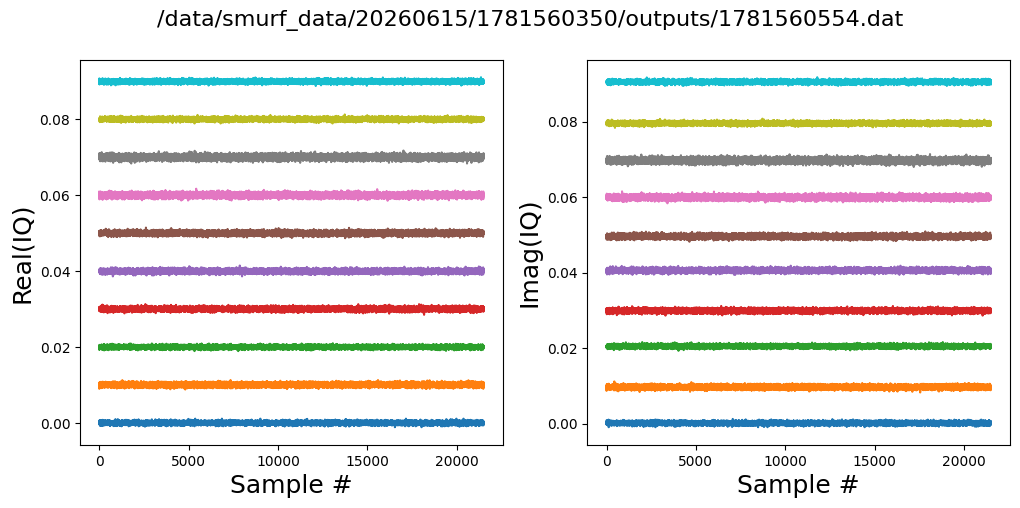

In [35]:
yoffset=1e-2

# Same plot as the working notebook, adapted for PreSpectra iq array
# iq shape: (n_frames, 32_timeslices, 64_slots)

# Flatten timeslices into the time axis: (n_frames*32, n_slots)
n_active = len(S.which_on(band))
d_new = iq[:, :, :n_active].reshape(-1, n_active).T  # shape: (n_active, n_samples)
  
# PreSpectra is Fixed16_14 — divide by 2^14 for physical units
# (the old bit_factor/accum_factor scaling doesn't apply to v0x04)
d_scaled = d_new / 2**14
  
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for ch in range(n_active):
    ych = d_scaled[ch]
    ymedian = np.median(ych)
    ax1.plot(np.real(ych - ymedian) + yoffset*ch)
    ax2.plot(np.imag(ych - ymedian) + yoffset*ch)
  
ax1.set_ylabel('Real(IQ)', fontsize=18)
ax1.set_xlabel('Sample #', fontsize=18)
ax2.set_ylabel('Imag(IQ)', fontsize=18)
ax2.set_xlabel('Sample #', fontsize=18)
fig.suptitle(data_file, fontsize=16)

# PSDs

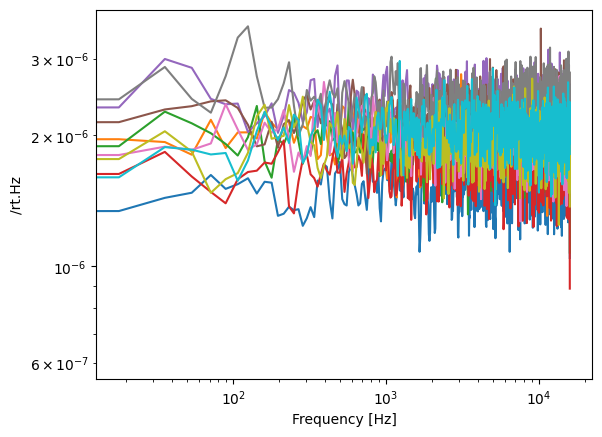

In [33]:
n_active = len(S.which_on(band))
d = (iq[:, :, :n_active].reshape(-1, n_active).T) / 2**14

# Effective sample rate: 32 timeslices × frame_rate
# frame_rate = flux_ramp_freq / 32, so effective fs = flux_ramp_freq
fs = S.get_flux_ramp_freq() * 1e3  # Hz

for ch in range(n_active):
    ych = d[ch]
    ymedian = np.median(ych)
  
    freq, pxx = signal.welch(np.abs(ych - ymedian), nperseg=len(ych)//12, fs=fs)
    plt.loglog(freq, np.sqrt(pxx))
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('/rt.Hz')

In [64]:
S.save_state('/data/smurf_data/zcu208-cryo-det-PreSpectra-rogue6-7d4fca8-poststream.yml')

[ 2026-06-15 22:07:20 ]  ADC plot saved to /data/smurf_data/20260615/1781560350/plots/1781561237_adc0.png
[ 2026-06-15 22:07:20 ]  Saving raw adc data to /data/smurf_data/20260615/1781560350/outputs/1781561237_adc0


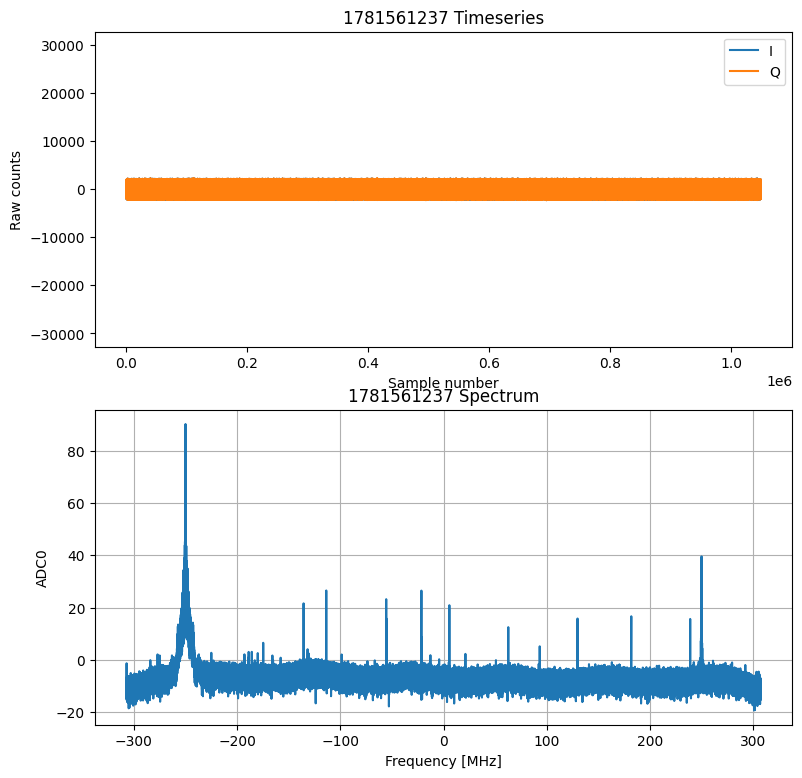

In [37]:
adc=S.read_adc_data(band = 0,make_plot=True,show_plot=True)

## QPD attempt 06/15/2026

Brandon says he has CPB QPDs spaced by just 15 MHz, sitting around 2.83 GHz. We may or may not see switching. Here is his message: "So 2.83 and 2.8446 I think. Should be pretty sharp resonances. Heads up that you may or may not see parity switching — these devices are very particular about setting Vg, so without setting it it may or may not show up, and they have rates on the order of 100 Hz"

In [22]:
f_QPD1 = 2830
f_QPD2 = 2844.6

In [16]:
S.all_off()

[ 2026-06-16 00:14:14 ]  Turning off tones
[ 2026-06-16 00:14:17 ]  Turning off flux ramp
[ 2026-06-16 00:14:17 ]  Turning off all TES biases


In [17]:
# Import useful wrapper functions

#sys.path.append("/home/cryo/docker/pysmurf/dev/v8.0.0-rc3_rfsoc/pysmurf/scratch/adroster")
from utils import *
#from parity_timestream import *

In [18]:
LO_freq_MHz = 2800 + 750

In [19]:
S.set_band_center_mhz(0,LO_freq_MHz-750)

In [20]:
S.get_band_center_mhz(band=0)

2800.0

In [45]:
n_avg = 1
f2, resp2 = freqSweep(S, band=0, start_freq=0, stop_freq=50, subband=None, tone_power=12, n_avg = n_avg
                      , makeplot=True)

[ 2026-06-16 00:21:56 ]  Sweeping across frequencies 2800.0MHz to 2850.0MHz. Averaging 1 traces.
[ 2026-06-16 00:21:56 ]  Working on band 0
[ 2026-06-16 00:21:58 ]  serial find freq complete


ValueError: could not broadcast input array from shape (1333,) into shape (1302,)

In [ ]:
amp = np.abs(resp2)
phase = np.angle(resp2)

In [ ]:
## plot the results
plt.figure(figsize=(7,8))
plt.subplot(2,1,1)
plt.plot(f2, amp)
#plt.plot(f3, invertedDoubleLorentzian(f3, *popt), 'r-', label = 'fit')
#plt.axvline(x=f0_1, color='r', linestyle='--', label=f'{f0_1} MHz')
#plt.axvline(x=f0_2, color='r', linestyle='--', label=f'{f0_2} MHz')
plt.axvline(x=f_QPD1, color='g', linestyle='--', label=f'{f_QPD1} MHz')
plt.axvline(x=f_QPD2, color='g', linestyle='--', label=f'{f_QPD2} MHz')
#plt.axis([8360,8380,-.0001,.0003])
plt.title('Magnitude')
plt.legend()
plt.subplot(2,1,2)
plt.plot(f2, phase)
plt.title('Phase')
plt.suptitle(f'CPB QPDs, frequency scan with {n_avg} averages')
plt.tight_layout(rect=[0, 0.03, 1.1, 0.95])
plt.show()